In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --------------------------------------
# 1. 加载数据
# --------------------------------------
freq_data = np.load("./datasets/awf1_freq.npz")

x = freq_data["x"]
y = freq_data["y"]

print(x.shape)
print(y.shape)

# --------------------------------------
# 2. 随机选择4个类别，每类10条
# --------------------------------------
random.seed(42)

classes = np.unique(y)
selected_classes = random.sample(list(classes), 4)

print("Selected classes:", selected_classes)

selected_index = []

for c in selected_classes:

    idx = np.where(y == c)[0]

    idx = np.random.choice(idx, 10, replace=False)

    selected_index.extend(idx)

selected_index = np.array(selected_index)

x_select = x[selected_index]
y_select = y[selected_index]

print(x_select.shape)

(249800, 2500)
(249800,)
Selected classes: [81.0, 14.0, 3.0, 94.0]
(40, 2500)


In [3]:
class TSNEDataset(Dataset):

    def __init__(self, x, y):

        self.x = x
        self.y = y

    def __len__(self):

        return len(self.x)

    def __getitem__(self, idx):

        return (
            torch.tensor(self.x[idx], dtype=torch.float32),
            self.y[idx]
        )


loader = DataLoader(
    TSNEDataset(x_select, y_select),
    batch_size=16,
    shuffle=False
)

In [4]:
class DFNet(nn.Module):
    def __init__(self, out_dim):
        super(DFNet, self).__init__()
        kernel_size = 8
        channels = [1, 32, 64, 128, 256]
        conv_stride = 1
        pool_stride = 4
        pool_size = 8
        
        self.conv1 = nn.Conv1d(1, 32, kernel_size, stride=conv_stride)
        self.conv1_1 = nn.Conv1d(32, 32, kernel_size, stride=conv_stride)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size, stride=conv_stride)
        self.conv2_2 = nn.Conv1d(64, 64, kernel_size, stride=conv_stride)
        
        self.conv3 = nn.Conv1d(64, 128, kernel_size, stride=conv_stride)
        self.conv3_3 = nn.Conv1d(128, 128, kernel_size, stride=conv_stride)
        
        self.conv4 = nn.Conv1d(128, 256, kernel_size, stride=conv_stride)
        self.conv4_4 = nn.Conv1d(256, 256, kernel_size, stride=conv_stride)
        
        self.batch_norm1 = nn.BatchNorm1d(32)
        self.batch_norm2 = nn.BatchNorm1d(64)
        self.batch_norm3 = nn.BatchNorm1d(128)
        self.batch_norm4 = nn.BatchNorm1d(256)
        
        self.max_pool_1 = nn.MaxPool1d(kernel_size=pool_size, stride=pool_stride)
        self.max_pool_2 = nn.MaxPool1d(kernel_size=pool_size, stride=pool_stride)
        self.max_pool_3 = nn.MaxPool1d(kernel_size=pool_size, stride=pool_stride)
        self.max_pool_4 = nn.MaxPool1d(kernel_size=pool_size, stride=pool_stride)
        
        self.dropout1 = nn.Dropout(p=0.1)
        self.dropout2 = nn.Dropout(p=0.1)
        self.dropout3 = nn.Dropout(p=0.1)
        self.dropout4 = nn.Dropout(p=0.1)
        
        self.fc = nn.Linear(2560, out_dim)

    def weight_init(self):
        for n, m in self.named_modules():
            if isinstance(m, nn.Linear) or isinstance(m, nn.Conv1d):
                torch.nn.init.xavier_uniform(m.weight)
                m.bias.data.zero_()
                
    def forward(self, inp):
        x = inp
        # ==== first block ====
        x = F.pad(x, (3,4))
        x = F.elu((self.conv1(x)))
        x = F.pad(x, (3,4))
        x = F.elu(self.batch_norm1(self.conv1_1(x)))
        x = F.pad(x, (3, 4))
        x = self.max_pool_1(x)
        x = self.dropout1(x)
        
        # ==== second block ====
        x = F.pad(x, (3,4))
        x = F.relu((self.conv2(x)))
        x = F.pad(x, (3,4))
        x = F.relu(self.batch_norm2(self.conv2_2(x)))
        x = F.pad(x, (3,4))
        x = self.max_pool_2(x)
        x = self.dropout2(x)
        
        # ==== third block ====
        x = F.pad(x, (3,4))
        x = F.relu((self.conv3(x)))
        x = F.pad(x, (3,4))
        x = F.relu(self.batch_norm3(self.conv3_3(x)))
        x = F.pad(x, (3,4))
        x = self.max_pool_3(x)
        x = self.dropout3(x)
        
        # ==== fourth block ====
        x = F.pad(x, (3,4))
        x = F.relu((self.conv4(x)))
        x = F.pad(x, (3,4))
        x = F.relu(self.batch_norm4(self.conv4_4(x)))
        x = F.pad(x, (3,4))
        x = self.max_pool_4(x)
        x = self.dropout4(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        
        return x 

class DFsimCLR(nn.Module):
    def __init__(self, df, out_dim):
        super(DFsimCLR, self).__init__()
        
        self.backbone = df
        self.backbone.weight_init()
        dim_mlp = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(dim_mlp, dim_mlp),
            nn.BatchNorm1d(dim_mlp),
            nn.ReLU(),
            nn.Linear(dim_mlp, out_dim)
        )
        
    def forward(self, inp):
        out = self.backbone(inp)
        return out

In [6]:
device = "cuda"

df = DFNet(out_dim=512)

model = DFsimCLR(df, out_dim=128)

model.load_state_dict(
    torch.load(
        "./checkpoints/WFTFC/WFTFC_freq_epoch_380.pth.tar",
        map_location=device
    )
)

model.to(device)

model.eval()

/tmp/ipykernel_1435/2535284605.py:42: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  torch.nn.init.xavier_uniform(m.weight)
/tmp/ipykernel_1435/1515753033.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. 

DFsimCLR(
  (backbone): DFNet(
    (conv1): Conv1d(1, 32, kernel_size=(8,), stride=(1,))
    (conv1_1): Conv1d(32, 32, kernel_size=(8,), stride=(1,))
    (conv2): Conv1d(32, 64, kernel_size=(8,), stride=(1,))
    (conv2_2): Conv1d(64, 64, kernel_size=(8,), stride=(1,))
    (conv3): Conv1d(64, 128, kernel_size=(8,), stride=(1,))
    (conv3_3): Conv1d(128, 128, kernel_size=(8,), stride=(1,))
    (conv4): Conv1d(128, 256, kernel_size=(8,), stride=(1,))
    (conv4_4): Conv1d(256, 256, kernel_size=(8,), stride=(1,))
    (batch_norm1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (batch_norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (batch_norm3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (batch_norm4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (max_pool_1): MaxPool1d(kernel_size=8, stride=4, padding=0, dilation=1, ceil_mode

In [7]:
feature_extractor = model.backbone

feature_extractor.fc = nn.Identity()

feature_extractor.eval()

DFNet(
  (conv1): Conv1d(1, 32, kernel_size=(8,), stride=(1,))
  (conv1_1): Conv1d(32, 32, kernel_size=(8,), stride=(1,))
  (conv2): Conv1d(32, 64, kernel_size=(8,), stride=(1,))
  (conv2_2): Conv1d(64, 64, kernel_size=(8,), stride=(1,))
  (conv3): Conv1d(64, 128, kernel_size=(8,), stride=(1,))
  (conv3_3): Conv1d(128, 128, kernel_size=(8,), stride=(1,))
  (conv4): Conv1d(128, 256, kernel_size=(8,), stride=(1,))
  (conv4_4): Conv1d(256, 256, kernel_size=(8,), stride=(1,))
  (batch_norm1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (max_pool_1): MaxPool1d(kernel_size=8, stride=4, padding=0, dilation=1, ceil_mode=False)
  (max_pool_2): MaxPool1d(kernel_size=8, s

In [8]:
import torch.nn.functional as F
features = []
labels = []

with torch.no_grad():

    for data, target in loader:

        data = data.unsqueeze(1).to(device)

        feat = feature_extractor(data)

        features.append(feat.cpu().numpy())

        labels.extend(target.numpy())

features = np.concatenate(features, axis=0)

labels = np.array(labels)

print(features.shape)


(40, 2560)


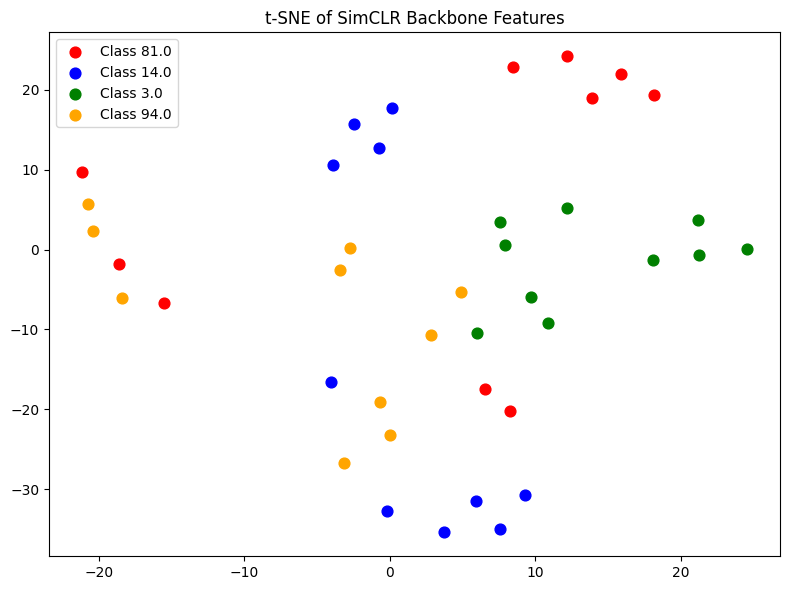

In [9]:
tsne = TSNE(
    n_components=2,
    perplexity=10,
    random_state=42
)

embedding = tsne.fit_transform(features)
plt.figure(figsize=(8,6))

colors = [
    "red",
    "blue",
    "green",
    "orange"
]

for i, cls in enumerate(selected_classes):

    mask = labels == cls

    plt.scatter(
        embedding[mask,0],
        embedding[mask,1],
        s=60,
        color=colors[i],
        label=f"Class {cls}"
    )

plt.legend()

plt.title("t-SNE of SimCLR Backbone Features")

plt.tight_layout()

plt.show()

## 看看128维的呢

cuda
(249800, 2500)
(249800,)
(120, 2500)
(120, 128)


/tmp/ipykernel_1435/2535284605.py:42: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  torch.nn.init.xavier_uniform(m.weight)
/tmp/ipykernel_1435/2721964934.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file.

(120, 2)


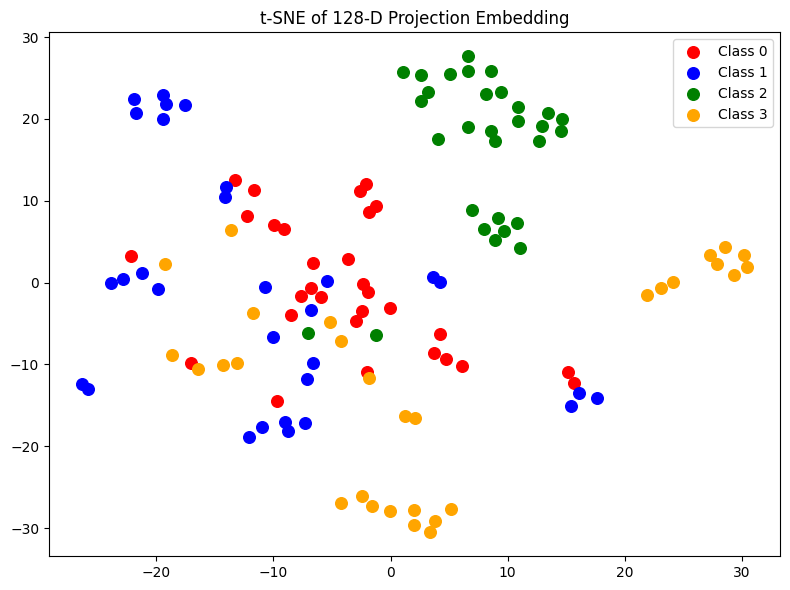

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

from sklearn.manifold import TSNE

import torch
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

data = np.load("./datasets/awf1_freq.npz")

x = data["x"]
y = data["y"]

print(x.shape)
print(y.shape)

selected_classes = [0,1,2,3]
# 采用随机c
# random.seed(42)
# selected_classes = random.sample(list(np.unique(y)),4)


selected_index = []

for c in selected_classes:

    idx = np.where(y==c)[0]

    idx = np.random.choice(idx,30,replace=False)

    selected_index.extend(idx)

selected_index=np.array(selected_index)

x=x[selected_index]
y=y[selected_index]

print(x.shape)
class TSNEDataset(Dataset):

    def __init__(self,x,y):

        self.x=x
        self.y=y

    def __len__(self):

        return len(self.x)

    def __getitem__(self,index):

        return torch.tensor(self.x[index],dtype=torch.float32),self.y[index]


loader=DataLoader(
    TSNEDataset(x,y),
    batch_size=16,
    shuffle=False
)
df = DFNet(out_dim=512)

model = DFsimCLR(df,out_dim=128)

checkpoint = torch.load(
    "./checkpoints/WFTFC/WFTFC_freq_epoch_380.pth.tar",
    map_location=device
)

model.load_state_dict(checkpoint)

model=model.to(device)

model.eval()
features=[]
labels=[]

with torch.no_grad():

    for data,target in loader:

        data=data.unsqueeze(1).to(device)

        embedding=model(data)

        features.append(embedding.cpu().numpy())

        labels.extend(target.numpy())

features=np.concatenate(features,axis=0)

labels=np.array(labels)

print(features.shape)
tsne=TSNE(
    n_components=2,
    perplexity=10,
    random_state=42
)

embedding_2d=tsne.fit_transform(features)

print(embedding_2d.shape)
plt.figure(figsize=(8,6))

colors=[
    "red",
    "blue",
    "green",
    "orange"
]

for i,c in enumerate(selected_classes):

    mask=labels==c

    plt.scatter(
        embedding_2d[mask,0],
        embedding_2d[mask,1],
        s=70,
        color=colors[i],
        label=f"Class {c}"
    )

plt.legend()

plt.title("t-SNE of 128-D Projection Embedding")

plt.tight_layout()

plt.show()



